# ch275 — Sampling

*(Depends on ch273 — Descriptive Statistics; connects to ch254 — Law of Large Numbers)*

## 1. The Problem of Inference

You want to know the average purchase value across all 2 million users. You have data from 500 of them. Under what conditions does the sample average tell you anything reliable about the population average?

The answer depends entirely on how those 500 users were selected. The sampling method is not a detail. It is the foundation of the entire inference.

---

## 2. Sampling Methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Population: 10,000 users with age and revenue
N = 10_000
pop_age     = rng.normal(35, 12, N).clip(18, 75)
pop_revenue = 20 + 2.5 * pop_age + rng.normal(0, 30, N)
pop_region  = rng.choice(['North', 'South', 'East', 'West'], N,
                          p=[0.4, 0.3, 0.2, 0.1])  # unequal strata

print(f"Population: N={N}")
print(f"True mean revenue: {pop_revenue.mean():.2f}")
print(f"True mean age:     {pop_age.mean():.2f}")

def simple_random_sample(arr: np.ndarray, n: int, rng) -> np.ndarray:
    """Each unit equally likely to be selected."""
    idx = rng.choice(len(arr), size=n, replace=False)
    return arr[idx], idx

def stratified_sample(
    arrays: list[np.ndarray],
    strata: np.ndarray,
    n_total: int,
    rng
) -> list[np.ndarray]:
    """
    Proportional stratified sampling.
    Allocates sample size proportional to stratum size.
    """
    unique_strata, counts = np.unique(strata, return_counts=True)
    proportions = counts / counts.sum()
    indices = []
    for stratum, prop in zip(unique_strata, proportions):
        n_s = max(1, round(n_total * prop))
        stratum_idx = np.where(strata == stratum)[0]
        sampled = rng.choice(stratum_idx, size=min(n_s, len(stratum_idx)), replace=False)
        indices.extend(sampled)
    indices = np.array(indices)
    return [a[indices] for a in arrays], indices

def convenience_sample(
    arr: np.ndarray, n: int, high_rev_only: bool = True
) -> np.ndarray:
    """
    Biased sample: only selects high-revenue users (e.g., active customers).
    """
    threshold = np.percentile(arr, 70)
    eligible  = np.where(arr >= threshold)[0]
    idx = rng.choice(eligible, size=min(n, len(eligible)), replace=False)
    return arr[idx], idx

n_sample = 300
srs_rev, srs_idx = simple_random_sample(pop_revenue, n_sample, rng)
(strat_rev, strat_age), strat_idx = stratified_sample(
    [pop_revenue, pop_age], pop_region, n_sample, rng)
conv_rev, conv_idx = convenience_sample(pop_revenue, n_sample)

print(f"\nSimple random sample mean:  {srs_rev.mean():.2f}")
print(f"Stratified sample mean:     {strat_rev.mean():.2f}")
print(f"Convenience sample mean:    {conv_rev.mean():.2f}  ← biased")
print(f"True population mean:       {pop_revenue.mean():.2f}")

Population: N=10000
True mean revenue: 108.93
True mean age:     35.33

Simple random sample mean:  111.61
Stratified sample mean:     107.79
Convenience sample mean:    158.02  ← biased
True population mean:       108.93


## 3. Sampling Distributions

The sample mean $\bar{X}$ is a random variable. Its distribution across repeated samples is the **sampling distribution**. Two critical facts:

1. $E[\bar{X}] = \mu$ — the sample mean is an unbiased estimator of the population mean
2. $\text{Var}(\bar{X}) = \sigma^2 / n$ — variance shrinks as sample size grows

The **standard error** is $\text{SE} = \sigma / \sqrt{n}$. It quantifies the precision of the sample mean as an estimate.

*(The Central Limit Theorem from ch254 guarantees that $\bar{X}$ is approximately normal regardless of the population distribution, for large enough n.)*

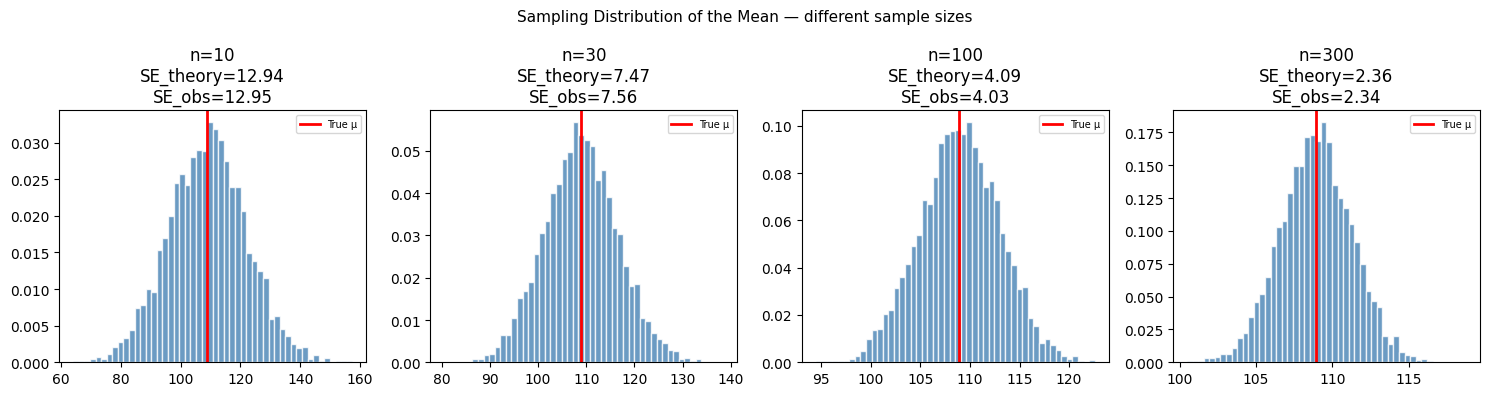

As n increases: sampling distribution narrows, mean stays centered at μ.


In [2]:
# Sampling distribution: repeat sampling many times
n_simulations = 5000
sample_sizes  = [10, 30, 100, 300]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
true_mean = pop_revenue.mean()
true_std  = pop_revenue.std()

for ax, n in zip(axes, sample_sizes):
    sample_means = np.array([
        pop_revenue[rng.choice(N, n, replace=False)].mean()
        for _ in range(n_simulations)
    ])
    ax.hist(sample_means, bins=50, color='steelblue', edgecolor='white',
            density=True, alpha=0.8)
    ax.axvline(true_mean, color='red', lw=2, label='True μ')
    se_theoretical = true_std / np.sqrt(n)
    se_empirical   = sample_means.std()
    ax.set_title(f'n={n}\nSE_theory={se_theoretical:.2f}\nSE_obs={se_empirical:.2f}')
    ax.legend(fontsize=7)

plt.suptitle('Sampling Distribution of the Mean — different sample sizes', fontsize=11)
plt.tight_layout()
plt.show()

print("As n increases: sampling distribution narrows, mean stays centered at μ.")

## 4. The Bias of Convenience Sampling

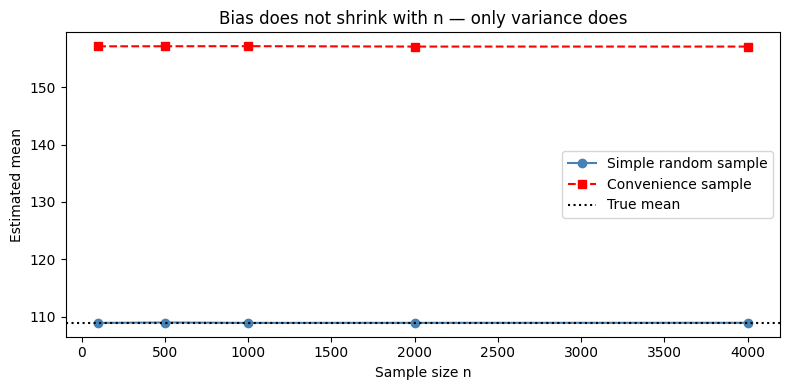

SRS converges to true mean. Convenience sample does not — regardless of n.


In [3]:
# Demonstrate that no amount of n fixes a biased sampling method
sample_sizes_large = [100, 500, 1000, 2000, 4000]

srs_means  = []
conv_means = []

for n in sample_sizes_large:
    srs_m = np.array([
        pop_revenue[rng.choice(N, n, replace=False)].mean()
        for _ in range(200)
    ]).mean()
    conv_m = np.array([
        convenience_sample(pop_revenue, n)[0].mean()
        for _ in range(200)
    ]).mean()
    srs_means.append(srs_m)
    conv_means.append(conv_m)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sample_sizes_large, srs_means, 'o-', color='steelblue', label='Simple random sample')
ax.plot(sample_sizes_large, conv_means, 's--', color='red', label='Convenience sample')
ax.axhline(pop_revenue.mean(), color='black', ls=':', label='True mean')
ax.set_xlabel('Sample size n')
ax.set_ylabel('Estimated mean')
ax.set_title('Bias does not shrink with n — only variance does')
ax.legend()
plt.tight_layout()
plt.show()

print("SRS converges to true mean. Convenience sample does not — regardless of n.")

## 5. Bootstrap: Estimating Sampling Distributions Without Knowing the Population

In practice, you have one sample. You cannot repeat the sampling process. The bootstrap approximates the sampling distribution by resampling with replacement from your observed sample.

Mean    : 111.97  95% CI [106.44, 117.80]
Median  : 111.72  95% CI [104.07, 117.90]
Std     : 40.63  95% CI [35.89, 45.65]


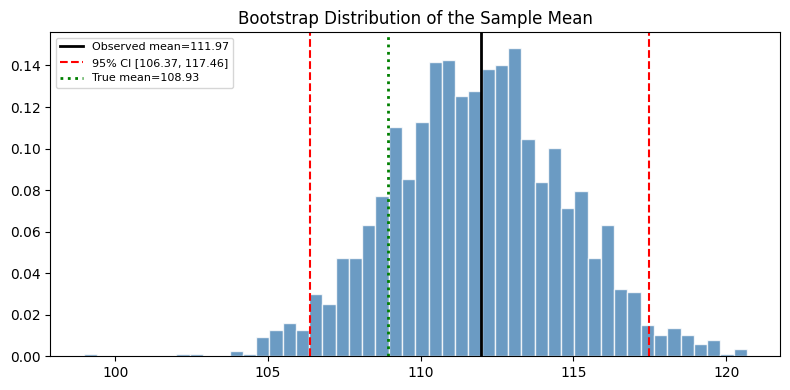

In [4]:
def bootstrap_ci(
    sample: np.ndarray,
    statistic_fn,
    n_bootstrap: int = 2000,
    alpha: float = 0.05,
    rng = None,
) -> tuple[float, float, float]:
    """
    Compute a bootstrap confidence interval for any statistic.
    Returns (observed_statistic, lower_bound, upper_bound).
    """
    if rng is None:
        rng = np.random.default_rng()
    n = len(sample)
    observed = statistic_fn(sample)
    boot_stats = np.array([
        statistic_fn(sample[rng.integers(0, n, size=n)])
        for _ in range(n_bootstrap)
    ])
    lo = np.percentile(boot_stats, 100 * alpha / 2)
    hi = np.percentile(boot_stats, 100 * (1 - alpha / 2))
    return observed, lo, hi, boot_stats

my_sample = pop_revenue[rng.choice(N, 200, replace=False)]

for name, fn in [
    ('Mean',   np.mean),
    ('Median', np.median),
    ('Std',    np.std),
]:
    obs, lo, hi, _ = bootstrap_ci(my_sample, fn, rng=rng)
    print(f"{name:<8}: {obs:.2f}  95% CI [{lo:.2f}, {hi:.2f}]")

# Visualize bootstrap distribution for the mean
obs, lo, hi, boot = bootstrap_ci(my_sample, np.mean, rng=rng)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot, bins=50, color='steelblue', edgecolor='white', density=True, alpha=0.8)
ax.axvline(obs, color='black', lw=2, label=f'Observed mean={obs:.2f}')
ax.axvline(lo,  color='red',   lw=1.5, ls='--', label=f'95% CI [{lo:.2f}, {hi:.2f}]')
ax.axvline(hi,  color='red',   lw=1.5, ls='--')
ax.axvline(pop_revenue.mean(), color='green', lw=2, ls=':', label=f'True mean={pop_revenue.mean():.2f}')
ax.set_title('Bootstrap Distribution of the Sample Mean')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Summary

| Method | Unbiased? | Requirements |
|---|---|---|
| Simple random sample | Yes | Full population accessible |
| Stratified sample | Yes (within strata) | Known strata structure |
| Cluster sample | Yes (if clusters representative) | Cheaper than SRS at scale |
| Convenience sample | No | — |
| Bootstrap | Asymptotically | One existing sample |

## 7. What Comes Next

With sampling distributions established, **ch276 — Bias and Variance** formalizes the tradeoff that determines model quality. The standard error computed here reappears in **ch279 — Confidence Intervals** as the key ingredient for constructing interval estimates. The bootstrap CI constructed in section 5 is the non-parametric version of the parametric interval developed in ch279.